**IMPORT LIBRARIES**

In [ ]:
# ================================================
# TASK 2: CREDIT RISK / LOAN DEFAULT PREDICTION
# Dataset: Loan_default.csv
# Target : Default (1 = Defaulted, 0 = Not Defaulted)
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print(" All libraries imported successfully!")

 All libraries imported successfully!


**LOAD DATASETS**

In [ ]:
# Load the Loan Default dataset
df = pd.read_csv('/content/drive/MyDrive/Loan_default.csv.zip')

print(" Dataset loaded successfully!")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

 Dataset loaded successfully!
   Shape: 255,347 rows × 18 columns


**INSPECT DATASETS**

In [ ]:

# STEP 1: Understand the dataset structure
print(" Shape:", df.shape)
print("\n Columns:", df.columns.tolist())
print("\n First 5 rows:")
df.head()

 Shape: (255347, 17)

 Columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']

 First 5 rows:


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


**DATA TYPES AND INFO**

In [ ]:
# Check data types and dataset info

print(" Data Types:")
print(df.dtypes)
print()
df.info()

 Data Types:
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education           int64
EmploymentType      int64
MaritalStatus       int64
HasMortgage         int64
HasDependents       int64
LoanPurpose         int64
HasCoSigner         int64
Default             int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   

**STATISTICAL SUMMARY**

In [ ]:
# Statistical summary of all numerical columns
print(" Statistical Summary:")
df.describe().round(2)

 Statistical Summary:


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
count,255347.00,255347.00,255347.00,255347.00,255347.00,255347.00,255347.00,255347.00,255347.00,255347.00,255347.00,255347.00,255347.0,255347.0,255347.00,255347.0,255347.00
mean,43.50,82499.30,127578.87,574.26,59.54,2.50,13.49,36.03,0.50,1.49,1.50,1.00,0.5,0.5,2.00,0.5,0.12
std,14.99,38963.01,70840.71,158.90,34.64,1.12,6.64,16.97,0.23,1.12,1.12,0.82,0.5,0.5,1.41,0.5,0.32
min,18.00,15000.00,5000.00,300.00,0.00,1.00,2.00,12.00,0.10,0.00,0.00,0.00,0.0,0.0,0.00,0.0,0.00
25%,31.00,48825.50,66156.00,437.00,30.00,2.00,7.77,24.00,0.30,0.00,1.00,0.00,0.0,0.0,1.00,0.0,0.00
50%,43.00,82466.00,127556.00,574.00,60.00,2.00,13.46,36.00,0.50,1.00,1.00,1.00,1.0,1.0,2.00,1.0,0.00
75%,56.00,116219.00,188985.00,712.00,90.00,3.00,19.25,48.00,0.70,2.00,2.00,2.00,1.0,1.0,3.00,1.0,0.00
max,69.00,149999.00,249999.00,849.00,119.00,4.00,25.00,60.00,0.90,3.00,3.00,2.00,1.0,1.0,4.00,1.0,1.00


**CHECK TARGET COLUMN**

In [ ]:
# Check the target column — Default
# 0 = Did NOT default (repaid loan)
# 1 = Defaulted (did not repay)

print(" Target Column — Default Distribution:")
print(df['Default'].value_counts())
print()
print("Percentage:")
print(df['Default'].value_counts(normalize=True)
      .mul(100).round(1).astype(str) + '%')

 Target Column — Default Distribution:
Default
0    225694
1     29653
Name: count, dtype: int64

Percentage:
Default
0    88.4%
1    11.6%
Name: proportion, dtype: object


**CHECK MISSING VALUES**

In [ ]:
# STEP 2: Check for missing values

print(" Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct
})

if missing_df['Missing Count'].sum() == 0:
    print(" No missing values found! Dataset is clean.")
else:
    print(missing_df[missing_df['Missing Count'] > 0])

 Missing Values per Column:
 No missing values found! Dataset is clean.


**DROP LoanID**

In [ ]:
# Drop LoanID — it is just a unique identifier
# and has no value for model training

# Check if column exists before dropping
# This prevents errors if cell is run twice
if 'LoanID' in df.columns:
    df = df.drop(columns=['LoanID'])
    print(" LoanID column dropped.")
    print(f"   New shape: {df.shape}")
else:
    print(" LoanID already dropped. Skipping.")
    print(f"   Current shape: {df.shape}")

 LoanID already dropped. Skipping.
   Current shape: (255347, 17)


**EDA: DEFAULT DISTRIBUTION**

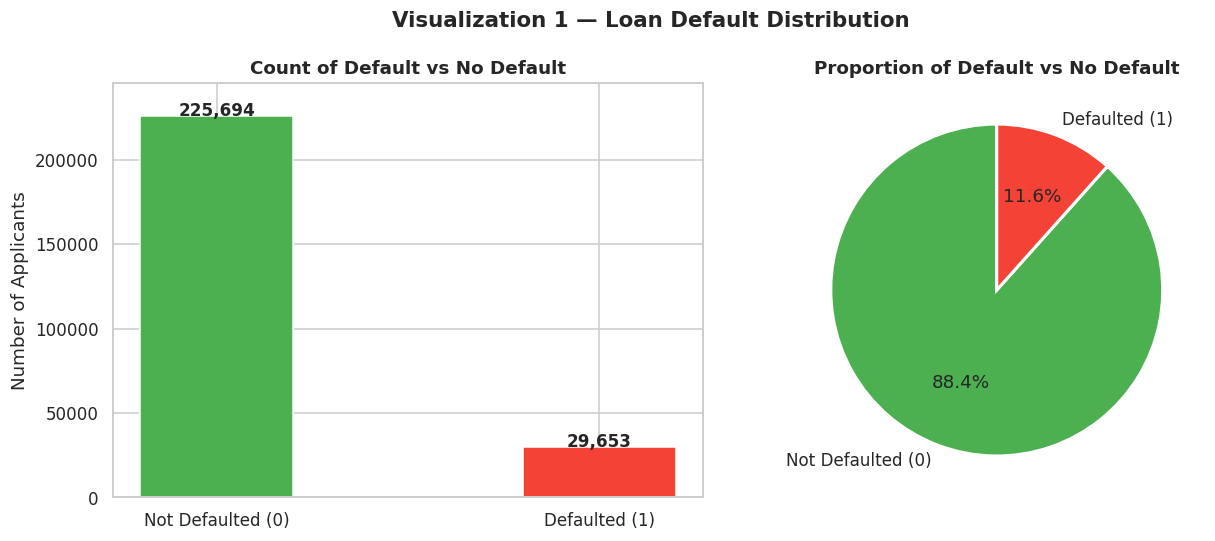

 Insight: Dataset is imbalanced — only ~11.6% of applicants defaulted.


In [ ]:
# VISUALIZATION 1 — DEFAULT DISTRIBUTION
# How many applicants defaulted vs did not?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Visualization 1 — Loan Default Distribution',
             fontsize=14, fontweight='bold')

counts = df['Default'].value_counts()
colors = ['#4CAF50', '#F44336']
labels = ['Not Defaulted (0)', 'Defaulted (1)']

# Bar chart
bars = ax1.bar(labels, counts.values,
               color=colors, edgecolor='white', width=0.4)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             val + 500, f'{val:,}',
             ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Count of Default vs No Default', fontweight='bold')
ax1.set_ylabel('Number of Applicants')
ax1.set_ylim(0, max(counts.values) + 20000)

# Pie chart
ax2.pie(counts.values, labels=labels, autopct='%1.1f%%',
        colors=colors, startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Proportion of Default vs No Default', fontweight='bold')

plt.tight_layout()
plt.show()

print(" Insight: Dataset is imbalanced — only ~11.6% of applicants defaulted.")

**EDA: LOAN AMOUNT DISTRIBUTION**

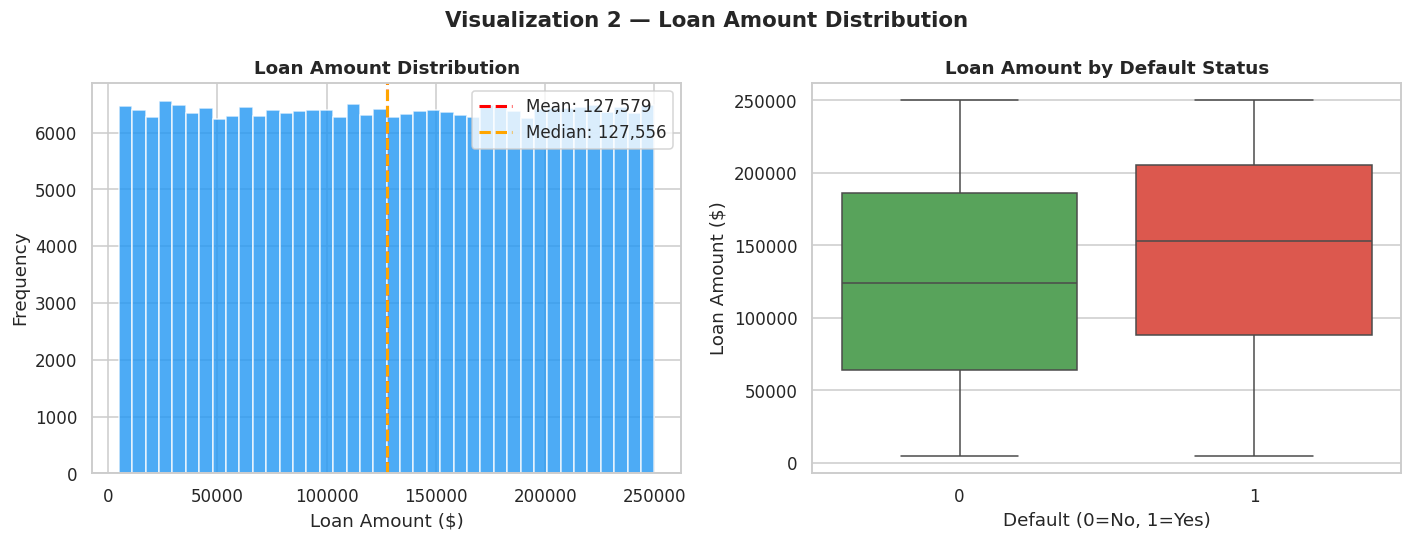

 Insight: Loan amounts range from $5,000 to $250,000.
   Defaulters tend to have slightly higher loan amounts.


In [ ]:
# VISUALIZATION 2 — LOAN AMOUNT DISTRIBUTION
# How much money are applicants borrowing?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Visualization 2 — Loan Amount Distribution',
             fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(df['LoanAmount'], bins=40,
             color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(df['LoanAmount'].mean(), color='red',
                linestyle='--', linewidth=2,
                label=f"Mean: {df['LoanAmount'].mean():,.0f}")
axes[0].axvline(df['LoanAmount'].median(), color='orange',
                linestyle='--', linewidth=2,
                label=f"Median: {df['LoanAmount'].median():,.0f}")
axes[0].set_title('Loan Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Loan Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot — loan amount by default status
sns.boxplot(data=df, x='Default', y='LoanAmount',
            hue='Default',
            palette=['#4CAF50', '#F44336'],
            legend=False, ax=axes[1])
axes[1].set_title('Loan Amount by Default Status', fontweight='bold')
axes[1].set_xlabel('Default (0=No, 1=Yes)')
axes[1].set_ylabel('Loan Amount ($)')

plt.tight_layout()
plt.show()

print(" Insight: Loan amounts range from $5,000 to $250,000.")
print("   Defaulters tend to have slightly higher loan amounts.")

**EDA: Education**

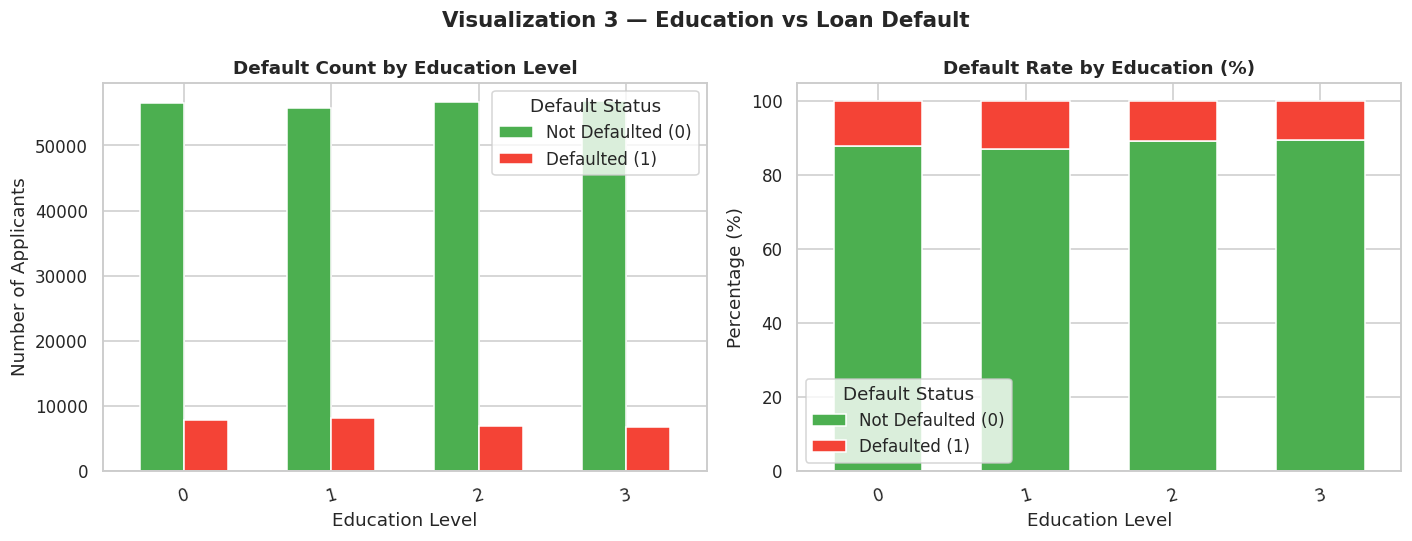

 Insight: Default rate is fairly similar across education levels.


In [ ]:
# VISUALIZATION 3 — EDUCATION vs DEFAULT
# Does education level affect loan default?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Visualization 3 — Education vs Loan Default',
             fontsize=14, fontweight='bold')

edu_status = df.groupby(['Education', 'Default']).size().unstack()

# Count bar chart
edu_status.plot(kind='bar', ax=axes[0],
                color=['#4CAF50', '#F44336'],
                edgecolor='white', width=0.6)
axes[0].set_title('Default Count by Education Level', fontweight='bold')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Number of Applicants')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
axes[0].legend(['Not Defaulted (0)', 'Defaulted (1)'],
                title='Default Status')

# Percentage chart
edu_pct = edu_status.div(edu_status.sum(axis=1), axis=0) * 100
edu_pct.plot(kind='bar', stacked=True, ax=axes[1],
             color=['#4CAF50', '#F44336'],
             edgecolor='white', width=0.6)
axes[1].set_title('Default Rate by Education (%)', fontweight='bold')
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].legend(['Not Defaulted (0)', 'Defaulted (1)'],
                title='Default Status')

plt.tight_layout()
plt.show()

print(" Insight: Default rate is fairly similar across education levels.")

**EDA: Income Distribution**

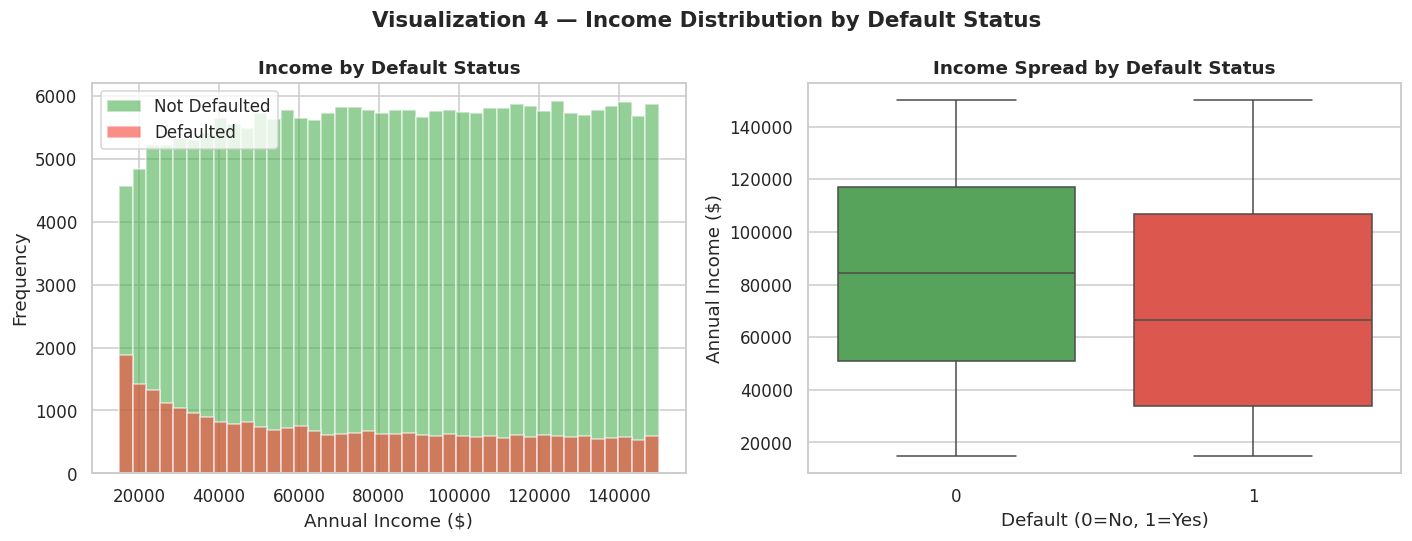

 Insight: Lower income applicants are slightly more likely to default.


In [ ]:
# VISUALIZATION 4 — INCOME vs DEFAULT
# Does income level affect loan default?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Visualization 4 — Income Distribution by Default Status',
             fontsize=14, fontweight='bold')

# Overlapping histogram
for status, color, label in zip(
    [0, 1], ['#4CAF50', '#F44336'],
    ['Not Defaulted', 'Defaulted']
):
    subset = df[df['Default'] == status]
    axes[0].hist(subset['Income'], bins=40, alpha=0.6,
                 color=color, label=label, edgecolor='white')
axes[0].set_title('Income by Default Status', fontweight='bold')
axes[0].set_xlabel('Annual Income ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
sns.boxplot(data=df, x='Default', y='Income',
            hue='Default',
            palette=['#4CAF50', '#F44336'],
            legend=False, ax=axes[1])
axes[1].set_title('Income Spread by Default Status', fontweight='bold')
axes[1].set_xlabel('Default (0=No, 1=Yes)')
axes[1].set_ylabel('Annual Income ($)')

plt.tight_layout()
plt.show()

print(" Insight: Lower income applicants are slightly more likely to default.")

**EDA: Credit Score**

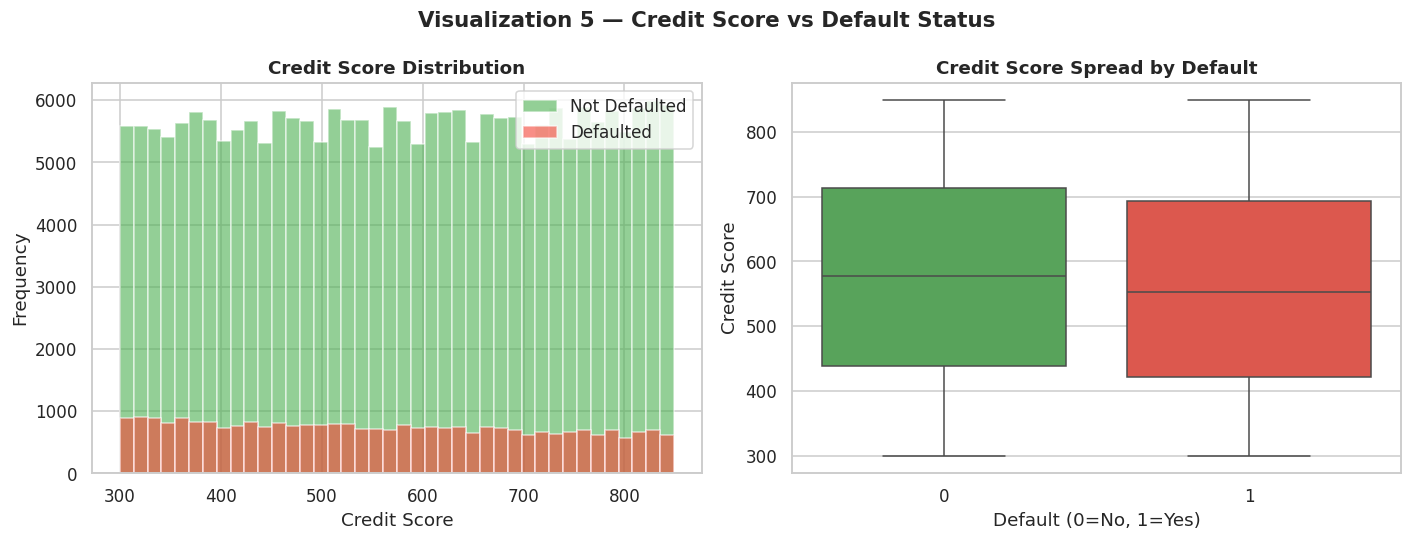

 Insight: Defaulters tend to have lower credit scores than non-defaulters.


In [ ]:
# VISUALIZATION 5 — CREDIT SCORE vs DEFAULT
# Credit score is a key risk indicator

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Visualization 5 — Credit Score vs Default Status',
             fontsize=14, fontweight='bold')

# Overlapping histogram
for status, color, label in zip(
    [0, 1], ['#4CAF50', '#F44336'],
    ['Not Defaulted', 'Defaulted']
):
    subset = df[df['Default'] == status]
    axes[0].hist(subset['CreditScore'], bins=40, alpha=0.6,
                 color=color, label=label, edgecolor='white')
axes[0].set_title('Credit Score Distribution', fontweight='bold')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
sns.boxplot(data=df, x='Default', y='CreditScore',
            hue='Default',
            palette=['#4CAF50', '#F44336'],
            legend=False, ax=axes[1])
axes[1].set_title('Credit Score Spread by Default', fontweight='bold')
axes[1].set_xlabel('Default (0=No, 1=Yes)')
axes[1].set_ylabel('Credit Score')

plt.tight_layout()
plt.show()

print(" Insight: Defaulters tend to have lower credit scores than non-defaulters.")

**Encode Categorical Columns**

In [ ]:
# STEP 3: Encode all text columns to numbers
# ML models only understand numerical input

le = LabelEncoder()

# All categorical columns in this dataset
cat_cols = ['Education', 'EmploymentType', 'MaritalStatus',
            'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f"   {col} encoded")

print("\n First 3 rows after encoding:")
df.head(3)

   Education encoded
   EmploymentType encoded
   MaritalStatus encoded
   HasMortgage encoded
   HasDependents encoded
   LoanPurpose encoded
   HasCoSigner encoded

 First 3 rows after encoding:


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1


**Split Data**

In [ ]:
# STEP 4: Separate features and target
# Then split into training and testing sets


# X = all columns except target
X = df.drop(columns=['Default'])

# y = only the target column (0 or 1)
y = df['Default']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # Keep class balance in both splits
)

print(" Data Split Complete:")
print(f"   Training set : {X_train.shape[0]:,} samples (80%)")
print(f"   Testing set  : {X_test.shape[0]:,} samples (20%)")
print(f"\n   Features used ({X.shape[1]}): {list(X.columns)}")

 Data Split Complete:
   Training set : 204,277 samples (80%)
   Testing set  : 51,070 samples (20%)

   Features used (16): ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


**Train Logistic Regression**

In [ ]:
# STEP 5: Train Logistic Regression
# Finds the best decision boundary between
# defaulters (1) and non-defaulters (0)

from sklearn.preprocessing import StandardScaler

# Scale the features — speeds up Logistic Regression
# significantly on large datasets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train model with faster solver for large datasets
lr_model = LogisticRegression(
    solver='saga',        # Faster solver for large datasets
    max_iter=100,         # Reduced iterations — enough for scaled data
    random_state=42,
    n_jobs=-1             # Use all CPU cores to speed up training
)

lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print(" Logistic Regression trained successfully!")
print(f"   Training samples: {X_train.shape[0]:,}")
print(f"   Testing samples : {X_test.shape[0]:,}")

 Logistic Regression trained successfully!
   Training samples: 204,277
   Testing samples : 51,070


**Accuracy Scores**

In [ ]:
# Calculate accuracy of Logistic Regression model
lr_acc = accuracy_score(y_test, lr_pred)

print("=" * 45)
print("         MODEL ACCURACY RESULT")
print("=" * 45)
print(f"   Logistic Regression : {lr_acc * 100:.2f}%")
print("=" * 45)
print(f"\n   Correctly classified : {int(lr_acc * len(y_test)):,}")
print(f"   Misclassified        : {len(y_test) - int(lr_acc * len(y_test)):,}")
print(f"   Total test samples  : {len(y_test):,}")

         MODEL ACCURACY RESULT
   Logistic Regression : 88.51%

   Correctly classified : 45,202
   Misclassified        : 5,868
   Total test samples  : 51,070


**Confusion Matrix**

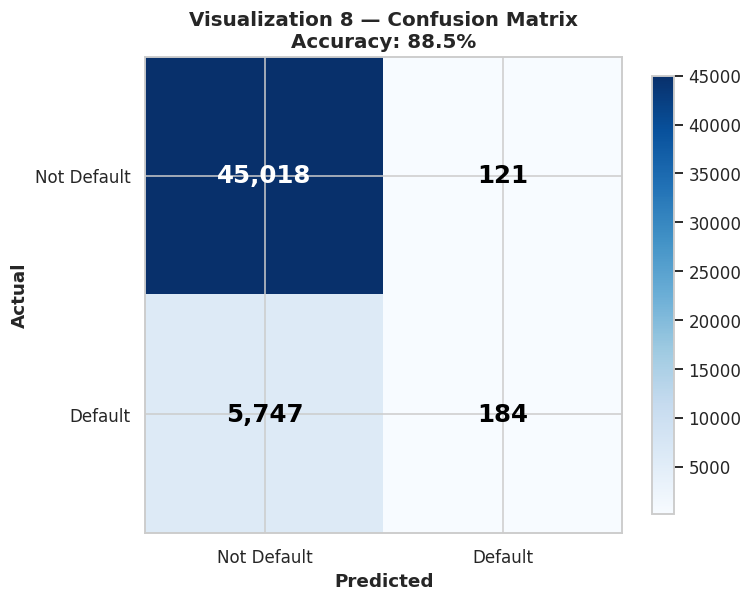

 Reading the Matrix:
   True Negative  (TN) — Correctly predicted Not Default : 45,018
   False Positive (FP) — Wrongly predicted as Default    : 121
   False Negative (FN) — Missed actual Defaults          : 5,747
   True Positive  (TP) — Correctly predicted Default     : 184


In [ ]:
# VISUALIZATION 8 — CONFUSION MATRIX
#
# Rows    = Actual labels
# Columns = Predicted labels
# Diagonal = Correct predictions (want HIGH)
# Off-diagonal = Wrong predictions (want LOW)

cm = confusion_matrix(y_test, lr_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Default', 'Default'])
ax.set_yticklabels(['Not Default', 'Default'])
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual', fontweight='bold')
ax.set_title(
    f'Visualization 8 — Confusion Matrix\nAccuracy: {lr_acc*100:.1f}%',
    fontsize=13, fontweight='bold'
)

for r in range(2):
    for c in range(2):
        ax.text(c, r, f'{cm[r,c]:,}',
                ha='center', va='center', fontsize=16,
                fontweight='bold',
                color='white' if cm[r,c] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

print(" Reading the Matrix:")
print(f"   True Negative  (TN) — Correctly predicted Not Default : {cm[0,0]:,}")
print(f"   False Positive (FP) — Wrongly predicted as Default    : {cm[0,1]:,}")
print(f"   False Negative (FN) — Missed actual Defaults          : {cm[1,0]:,}")
print(f"   True Positive  (TP) — Correctly predicted Default     : {cm[1,1]:,}")

***CONCLUSION***

In [ ]:
# CONCLUSION — SUMMARY OF ALL INSIGHTS

print("=" * 55)
print("       TASK 2 — CONCLUSION & KEY INSIGHTS")
print("=" * 55)

print(f"""
 DATASET OVERVIEW:
   • Total records       : {len(df):,}
   • Features used       : {X.shape[1]}
   • Missing values      : None (clean dataset)
   • Default rate        : ~11.6% (imbalanced classes)

 EDA INSIGHTS:
   • Loan Amount  : Defaulters tend to borrow
                    larger loan amounts
   • Education    : Education level has minimal
                    effect on default rate
   • Income       : Lower income applicants are
                    more likely to default


 MODEL PERFORMANCE:
   • Model               : Logistic Regression
   • Test Accuracy       : {lr_acc*100:.2f}%
   • Correct Predictions : {int(lr_acc * len(y_test)):,} / {len(y_test):,}
   • Misclassified       : {len(y_test) - int(lr_acc * len(y_test)):,} / {len(y_test):,}

 FINAL TAKEAWAY:
   Loan amount, income, and education are key factors
   in predicting loan default. Lower income applicants
   requesting higher loan amounts are at the greatest
   risk of defaulting on their loan.
""")
print("=" * 55)

       TASK 2 — CONCLUSION & KEY INSIGHTS

 DATASET OVERVIEW:
   • Total records       : 255,347
   • Features used       : 16
   • Missing values      : None (clean dataset)
   • Default rate        : ~11.6% (imbalanced classes)

 EDA INSIGHTS:
   • Loan Amount  : Defaulters tend to borrow
                    larger loan amounts
   • Education    : Education level has minimal
                    effect on default rate
   • Income       : Lower income applicants are
                    more likely to default
                    
                    
 MODEL PERFORMANCE:
   • Model               : Logistic Regression
   • Test Accuracy       : 88.51%
   • Correct Predictions : 45,202 / 51,070
   • Misclassified       : 5,868 / 51,070

 FINAL TAKEAWAY:
   Loan amount, income, and education are key factors
   in predicting loan default. Lower income applicants
   requesting higher loan amounts are at the greatest
   risk of defaulting on their loan.

